In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#provided MHW value for your site in [m NAVD88]
MHW_ELEVATION_NAVD88 = 0.26 
#load the water level csv file for year 2024 [m NAVD88]
water_level_NAVD = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/Daily_WL_NAVD.csv'

#load water level
water_NAVD_df = pd.read_csv(water_level_NAVD) # (m NAVD88)
daily_tidal_levels_NAVD= water_NAVD_df['v'].values # (m NAVD88)
#converting daily water level (m NAVD88) to (m MHW)
daily_tidal_MHW = daily_tidal_levels_NAVD - MHW_ELEVATION_NAVD88 # (m MHW)

#loading CASCADE simulations
data = np.load (
    '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Nourishment_S0_Accretional_Sink.npz', allow_pickle=True)
data

NpzFile '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/OCR_I_Nourishment_S0_Accretional_Sink.npz' with keys: cascade

In [80]:
#cascade object
cascade_object = data['cascade'][0]

In [81]:
#exporting road elevations (m MHW) for each domain categorized by the years
results_list = []
target_years = range(75,101,1)
 
if not cascade_object.roadways:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")
else:
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways):
            
            # only DOMAINS 14 to 54
            if 14 <= i <= 54:
            
                elevation_time_series = road_segment._road_ele_TS
                elevation = elevation_time_series[year]
                elev_row = {
                    'Year': year,
                    'Domain': i,
                    'Road_Elevation (m MHW)': elevation
                }
                results_list.append(elev_row)

#convert the list to a DataFrame and save it
if results_list:
    # Convert the list of dictionaries into a pandas DataFrame
    road_df = pd.DataFrame(results_list)
    output_filename = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/year75to100/OCR_I_Nourishment_S0_Accretional_Sink_RoadElevation75to100.csv'

    road_df.to_csv(output_filename, index=False)
    print("Data for domains 14-54 successfully exported. First 5 rows:")
    print(road_df.head())

Data for domains 14-54 successfully exported. First 5 rows:
   Year  Domain  Road_Elevation (m MHW)
0    75      14                     0.0
1    75      15                     0.0
2    75      16                     0.0
3    75      17                     0.0
4    75      18                     0.0


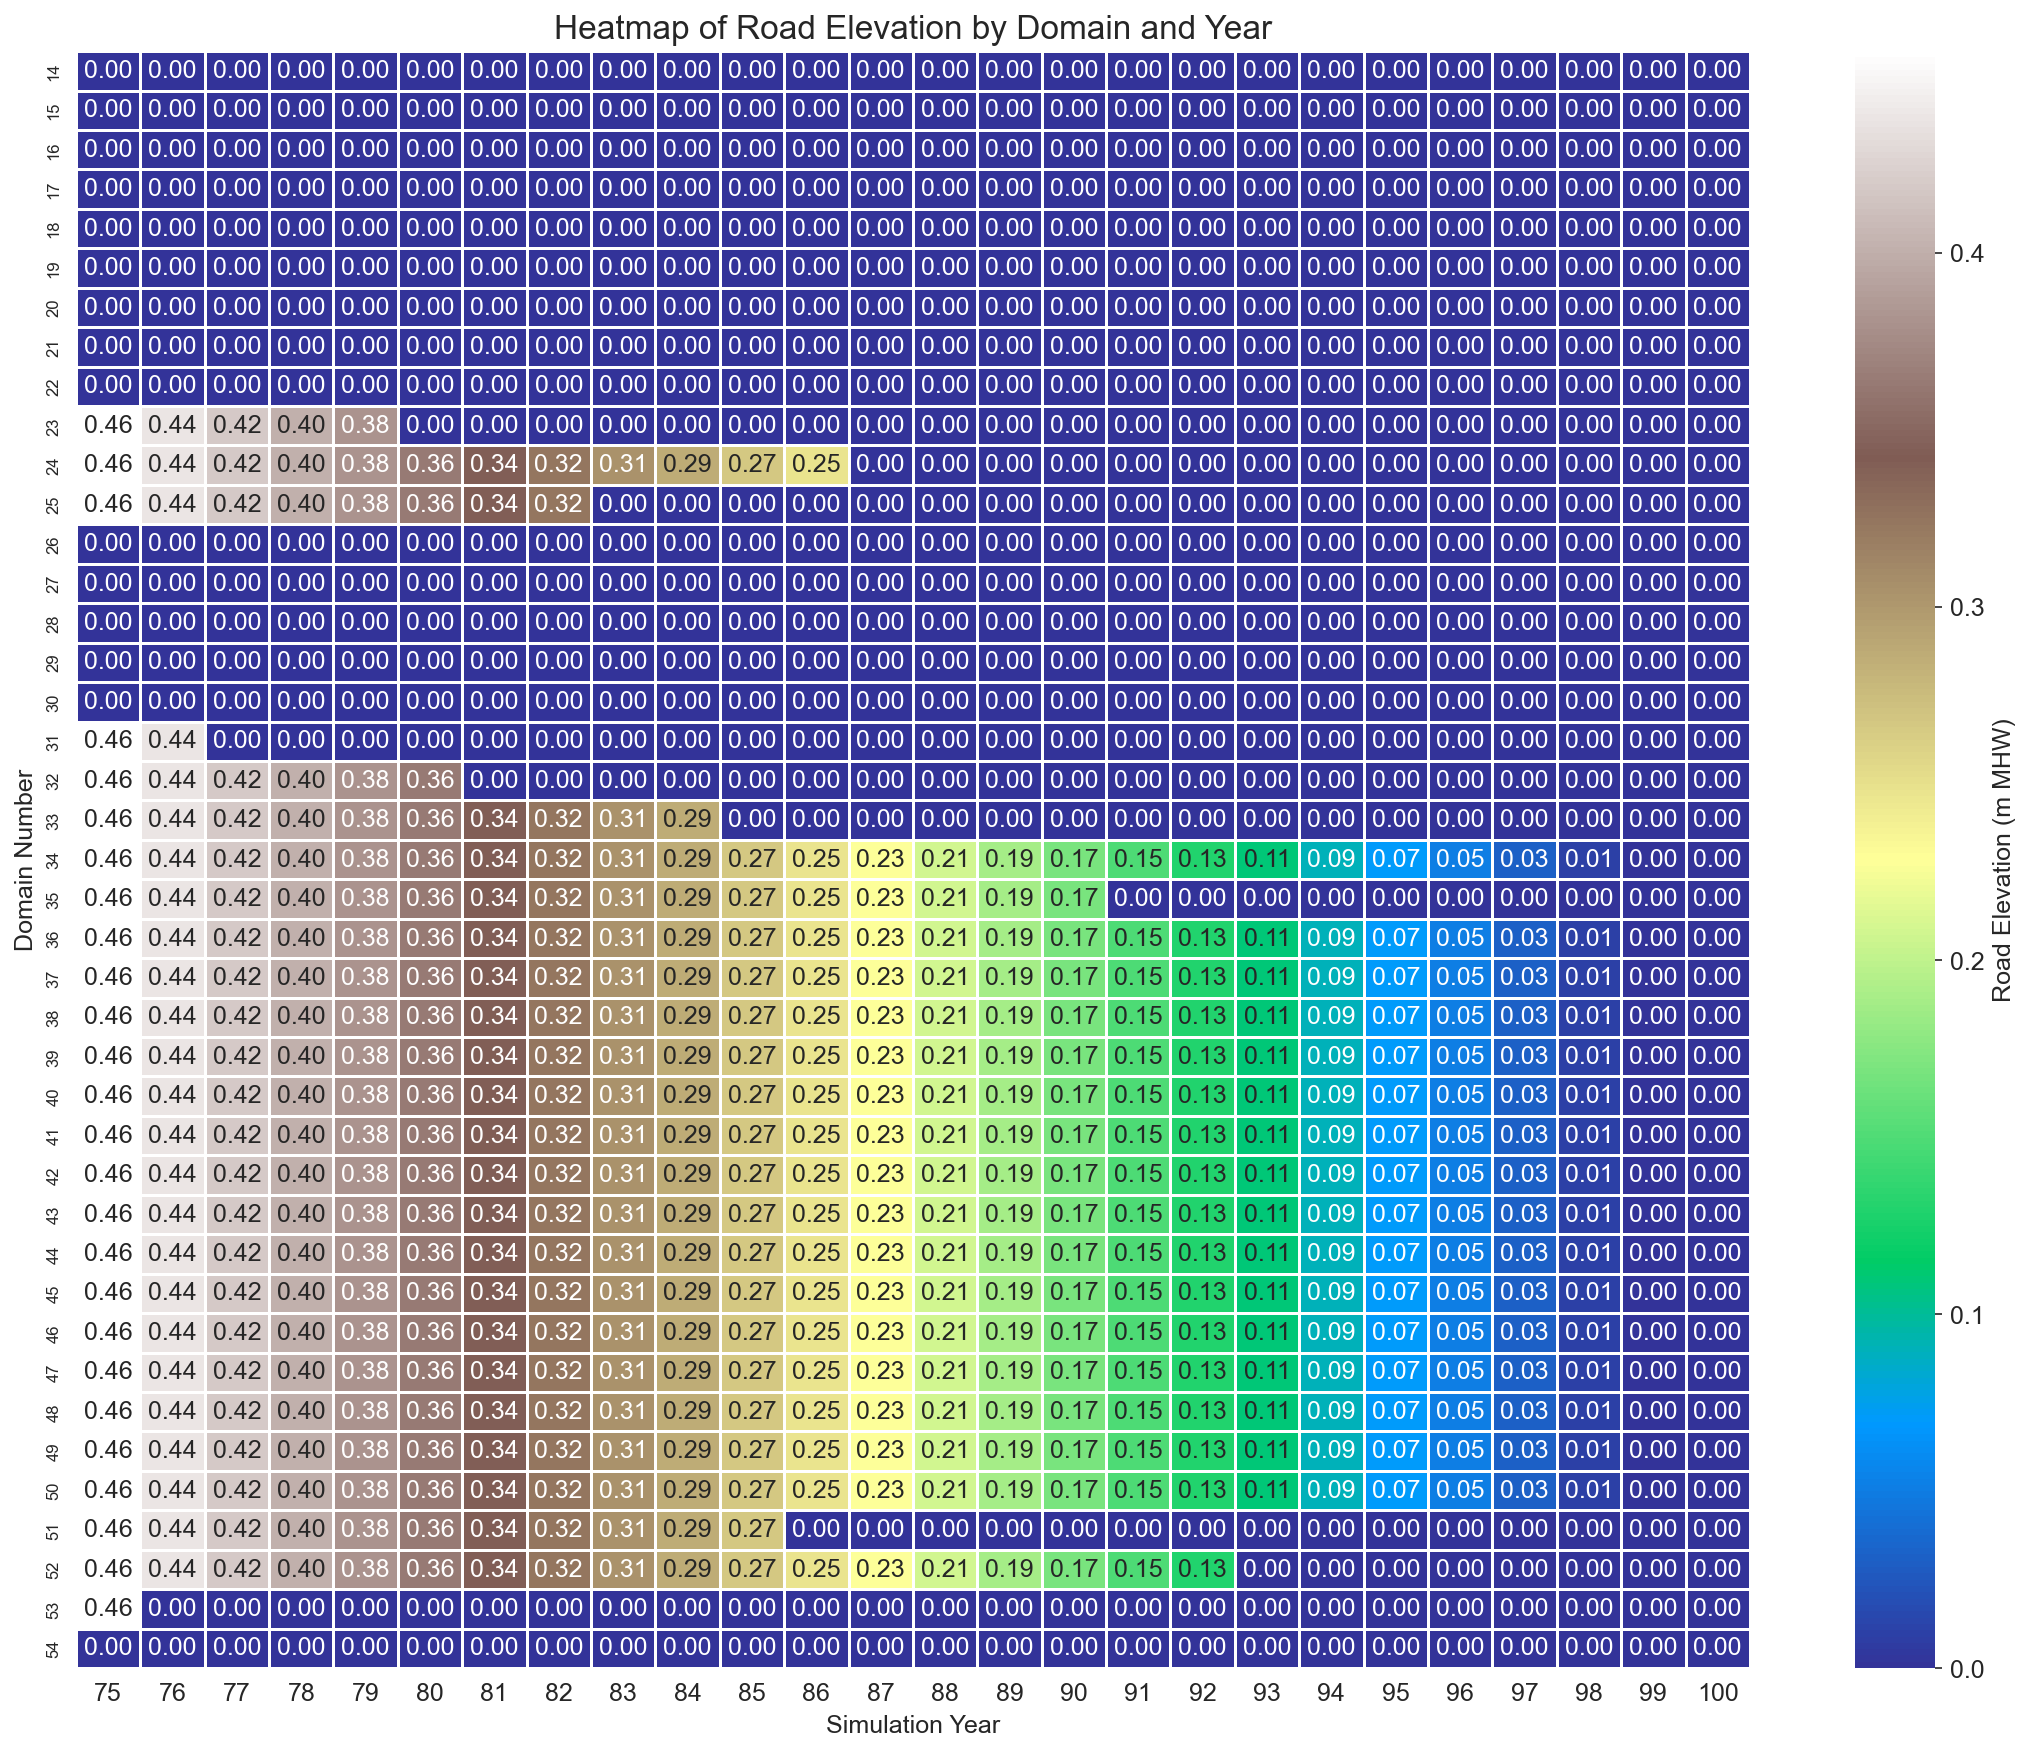

In [82]:
#plotting road elevation
# Load the CSV file into a DataFrame
file_path = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/year75to100/OCR_I_Nourishment_S0_Accretional_Sink_RoadElevation75to100.csv'
df = pd.read_csv(file_path)

# Reshape the data using a pivot_table for the heatmap
heatmap_data = df.pivot_table(index='Domain', columns='Year', values='Road_Elevation (m MHW)')

# Create the heatmap plot
plt.figure(figsize=(18, 14), dpi=150)
ax = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".2f", 
                 cmap='terrain', 
                 linewidths=.5,
                 cbar_kws={'label': 'Road Elevation (m MHW)'})


ax.tick_params(axis='y', labelsize=8)

plt.title('Heatmap of Road Elevation by Domain and Year', fontsize=16)
plt.ylabel('Domain Number', fontsize=12)
plt.xlabel('Simulation Year', fontsize=12)

# Show the plot
plt.show()

In [83]:
#export flood days to csv
analysis_output_filepath = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/year75to100/OCR_I_Nourishment_S0_Accretional_Sink_flood_days75to100.csv'
print(f"\n Loading data and running analysis:")
part1_success = False
results_df = None
print("Successfully loaded all input files (skipped header in water level file).")

# Perform the comparison
final_results = []
for index, road_row in road_df.iterrows():
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation (m MHW)']
    flooded_days = np.sum(road_elevation < daily_tidal_MHW)
    
    result_row = {
        'Year': year,
        'Domain': domain,
        'Road_Elevation': road_elevation,
        'Flooded_Days': flooded_days,
    }
    final_results.append(result_row)

# Save the analysis results to a CSV file
results_df = pd.DataFrame(final_results)
results_df.to_csv(analysis_output_filepath, index=False)
print(f"Analysis complete. Results saved to '{analysis_output_filepath}'")


 Loading data and running analysis:
Successfully loaded all input files (skipped header in water level file).
Analysis complete. Results saved to '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/year75to100/OCR_I_Nourishment_S0_Accretional_Sink_flood_days75to100.csv'


In [84]:
road_elevation

np.float64(0.0)

In [85]:
#export flood depth to csv
analysis_output_filepath = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/year75to100/OCR_I_Nourishment_S0_Accretional_Sink_flood_depth75to100.csv'
print(f"\n Loading data and running analysis:")
part1_success = False
results_df = None
print("Successfully loaded all input files (skipped header in water level file).")

# Perform the comparison
final_results = []
for index, road_row in road_df.iterrows():
    year = int(road_row['Year'])
    domain = int(road_row['Domain'])
    road_elevation = road_row['Road_Elevation (m MHW)']
    
    # flood days and depth analysis
    # Identify which days are flooded
    is_flooded = road_elevation < daily_tidal_MHW
    flooded_days = np.sum(is_flooded)
    
    # Calculate flood depth only on the days it flooded
    max_flood_depth = 0
    avg_flood_depth = 0
    
    if flooded_days > 0:
        # Calculate the depth for all flooded days
        flood_depths = daily_tidal_MHW[is_flooded] - road_elevation # (m MHW)
        
        # Find the maximum and average flood depth for the year
        max_flood_depth = np.max(flood_depths)
        avg_flood_depth = np.mean(flood_depths)

    # export the results
        
    result_row = {
        'Year': year,
        'Domain': domain,
        'Road_Elevation': road_elevation, # (m MHW)
        'Flooded_Days': flooded_days,
        'Max_Flood_Depth_m_MHW': max_flood_depth,   # (m MHW)
        'Avg_Flood_Depth_m_MHW': avg_flood_depth,   # (m MHW)
    }
    final_results.append(result_row)

# Save the analysis results to a CSV file
results_df = pd.DataFrame(final_results)
results_df.to_csv(analysis_output_filepath, index=False)
print(f"Analysis complete. Results saved to '{analysis_output_filepath}'")


 Loading data and running analysis:
Successfully loaded all input files (skipped header in water level file).
Analysis complete. Results saved to '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/year75to100/OCR_I_Nourishment_S0_Accretional_Sink_flood_depth75to100.csv'


  > Plot saved as '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/year75to100/OCR_I_Nourishment_S0_Accretional_Sink75to100.png'


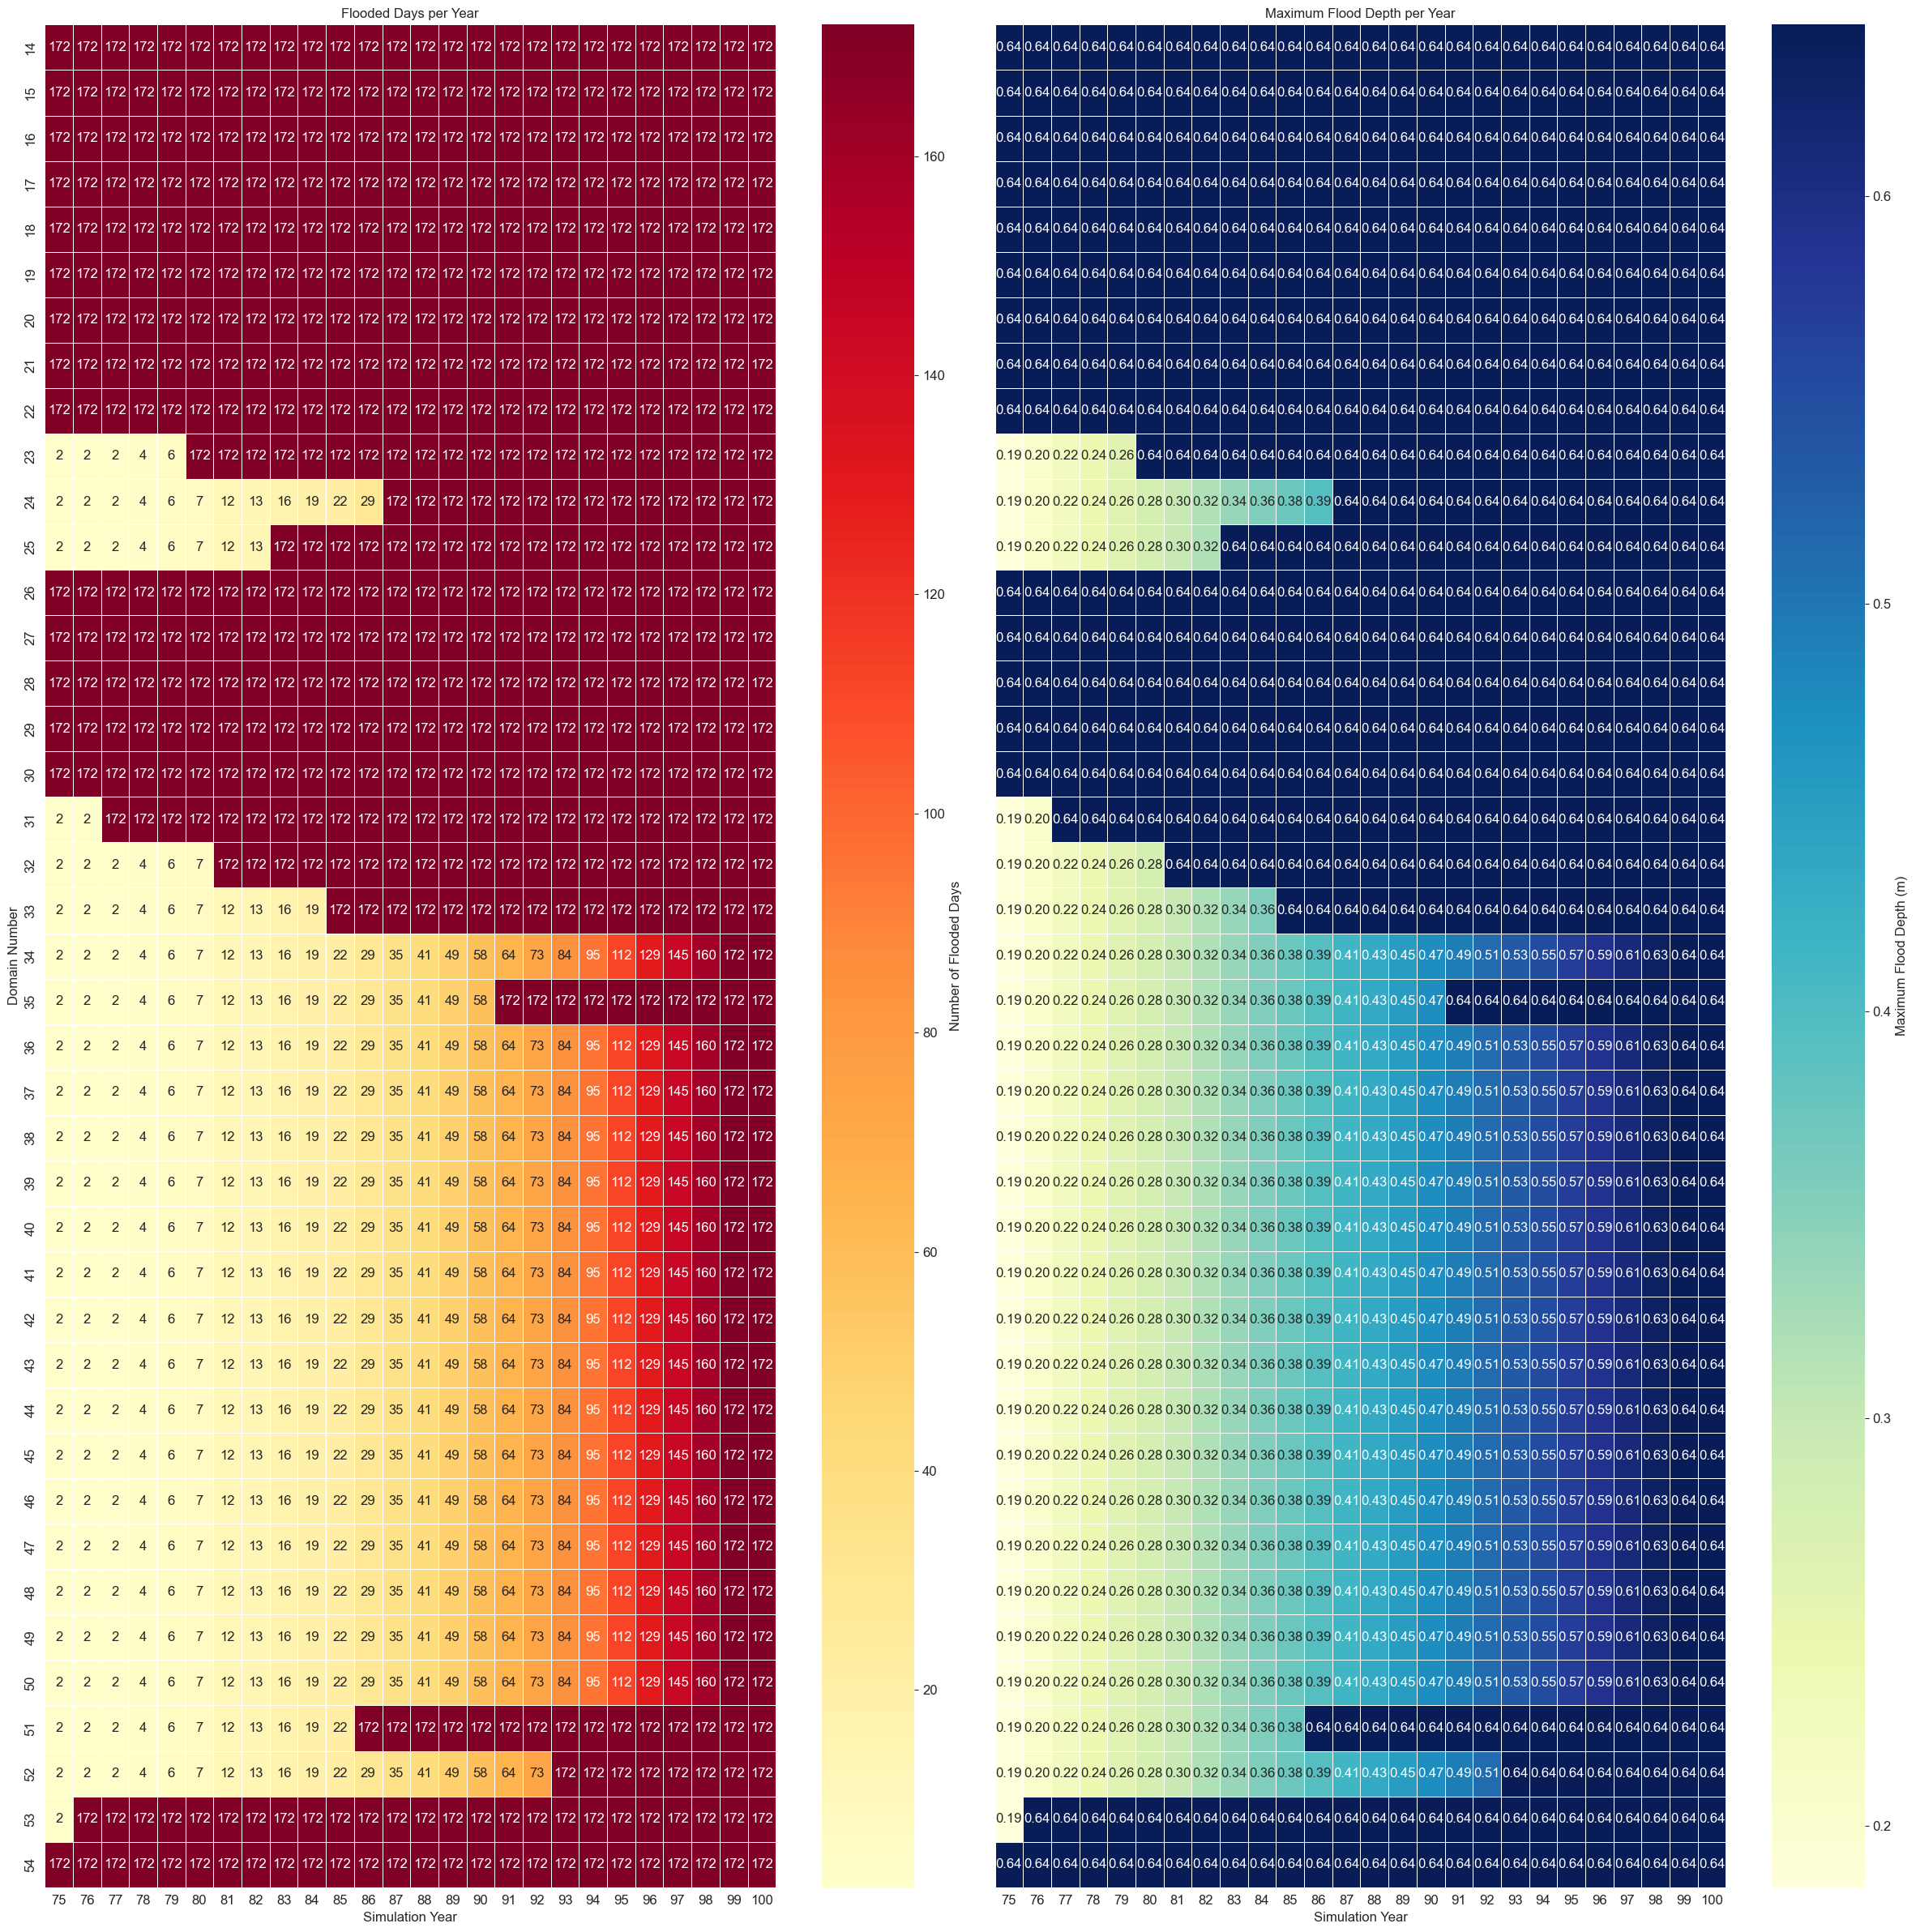

In [86]:
plt.rcParams.update({'font.size': 12})
# Create two pivot tables, one for each variable
heatmap_days = results_df.pivot_table(index='Domain', columns='Year', values='Flooded_Days')
heatmap_depth = results_df.pivot_table(index='Domain', columns='Year', values='Max_Flood_Depth_m_MHW')

# Create a figure with two subplots 
fig, axes = plt.subplots(1, 2, figsize=(24, 24), sharey=True) # sharey=True aligns the domain rows
sns.set_style("whitegrid")

text_props = dict(ha='center', va='center', fontsize=12, color='black', weight='bold')
bbox_props = dict(boxstyle='round,pad=0.5', fc='white', ec='black', lw=1, alpha=0.8)

# Plot 1: Flooded Days 
sns.heatmap(heatmap_days, ax=axes[0], annot=True, fmt=".0f", cmap='YlOrRd', 
            linewidths=.5, cbar_kws={'label': 'Number of Flooded Days'})
axes[0].set_title('Flooded Days per Year', fontsize=12)
axes[0].set_ylabel('Domain Number', fontsize=12)
axes[0].set_xlabel('Simulation Year', fontsize=12)

# Plot 2: Maximum Flood Depth 
sns.heatmap(heatmap_depth, ax=axes[1], annot=True, fmt=".2f", cmap='YlGnBu', 
            linewidths=.5, cbar_kws={'label': 'Maximum Flood Depth (m)'})
axes[1].set_title('Maximum Flood Depth per Year', fontsize=12)
axes[1].set_ylabel('') # Hide the y-label to avoid repetition
axes[1].set_xlabel('Simulation Year', fontsize=12)
# plt.text(1.75, 7.5, 'Buffer Zone', **text_props, bbox=bbox_props)
# plt.text(1.75, 34.5, 'Ocracoke Island', **text_props, bbox=bbox_props)
# plt.text(1.75, 61.5, 'Buffer Zone', **text_props, bbox=bbox_props)

# Add horizontal lines to both plots
for ax in axes:
    # ax.axhline(y=15, color='black', linestyle='--', linewidth=3)
    # ax.axhline(y=54, color='black', linestyle='--', linewidth=3)
    ax.set_xticklabels(['75', '76', '77', '78', '79',
 '80', '81', '82', '83', '84',
 '85', '86', '87', '88', '89',
 '90', '91', '92', '93', '94',
 '95', '96', '97', '98', '99', '100']) 

plt.tight_layout() # Adjusts plots to prevent them from overlapping


plot_output_filename = f'/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/year75to100/OCR_I_Nourishment_S0_Accretional_Sink75to100.png'
plt.savefig(plot_output_filename, bbox_inches='tight')
print(f"  > Plot saved as '{plot_output_filename}'")
plt.show()

In [87]:
#saving variables
results_list = []

# Determine the number of years from the simulation output
# and create a list of all years to process.
if cascade_object.roadways:
    target_years = range(75,101,1)

    # Use nested loops to iterate through each year and each domain
    for year in target_years:
        for i, road_segment in enumerate(cascade_object.roadways[14:55], start=14):
            # Get the corresponding barrier3d segment for the same domain
            barrier3d_segment = cascade_object.barrier3d[i]
            
            # Extract each variable for the current year and domain
            # We use a try-except block to handle potential missing data gracefully
            try:
                elevation = road_segment._road_ele_TS[year]
                width = barrier3d_segment.InteriorWidth_AvgTS[year]
                setback = road_segment._road_setback_TS[year]
                qow = barrier3d_segment.QowTS[year]
                shoreline_change = barrier3d_segment.ShorelineChangeTS[year]
                dune_height = barrier3d_segment.Hd_AverageTS[year]
                overwash_vol = road_segment._road_overwash_volume[year]
                
                # Create a dictionary for the current row
                result_row = {
                    'Year': year,
                    'Domain': i,
                    'Elevation': elevation,
                    'InteriorWidth_Avg': width,
                    'RoadSetback': setback,
                    'Qow': qow,
                    'ShorelineChange': shoreline_change,
                    'AvgDuneHeight': dune_height,
                    'RoadOverwashVolume_m3': overwash_vol
                }
                results_list.append(result_row)
            
            except IndexError:
                print(f"Data for Year {year}, Domain {i} is not available. Skipping.")

    # Convert the list of dictionaries into a pandas DataFrame
    if results_list:
        results_df = pd.DataFrame(results_list)
        
        # Define a new output filename
        output_filename = '/Users/rsahrae/PycharmProjects/CASCADE_Coupling/CASCADE/scripts/FLOOD ANALYSIS/I scenario/I scenario/Accretional_Sink/All_years/year75to100/combined_cascade_variables.csv'
        
        # Save the DataFrame to the new CSV file
        results_df.to_csv(output_filename, index=False)
        
        print(f"All specified variables successfully exported to '{output_filename}'")
        print("First 5 rows of the new file:")
        print(results_df.head())
else:
    print("The 'roadways' attribute is empty. Cannot retrieve data.")

Data for Year 99, Domain 47 is not available. Skipping.
Data for Year 100, Domain 14 is not available. Skipping.
Data for Year 100, Domain 15 is not available. Skipping.
Data for Year 100, Domain 16 is not available. Skipping.
Data for Year 100, Domain 17 is not available. Skipping.
Data for Year 100, Domain 18 is not available. Skipping.
Data for Year 100, Domain 19 is not available. Skipping.
Data for Year 100, Domain 20 is not available. Skipping.
Data for Year 100, Domain 21 is not available. Skipping.
Data for Year 100, Domain 22 is not available. Skipping.
Data for Year 100, Domain 23 is not available. Skipping.
Data for Year 100, Domain 24 is not available. Skipping.
Data for Year 100, Domain 25 is not available. Skipping.
Data for Year 100, Domain 26 is not available. Skipping.
Data for Year 100, Domain 27 is not available. Skipping.
Data for Year 100, Domain 28 is not available. Skipping.
Data for Year 100, Domain 29 is not available. Skipping.
Data for Year 100, Domain 30 is 

In [88]:
i = 0 
for b3d_id, b3d in enumerate(cascade_object.barrier3d):
    
    if (b3d.drown_break):
        i+=1
        print(f"barrier domain number {b3d_id} drowned")
print(f"total number of drowned barrier segments: {i}")

barrier domain number 47 drowned
total number of drowned barrier segments: 1


In [89]:
cascade_object.roadways[34]._road_ele_TS

array([1.45      , 1.44356886, 1.43696258, 1.43017863, 1.42321453,
       1.41606791, 1.40873648, 1.40121805, 1.39351055, 1.38561201,
       1.37752057, 1.3692345 , 1.3607522 , 1.3520722 , 1.34319314,
       1.33411384, 1.32483323, 1.31535041, 1.3056646 , 1.29577519,
       1.28568172, 1.27538389, 1.26488154, 1.25417467, 1.24326343,
       1.23214815, 1.22082928, 1.20930744, 1.1975834 , 1.18565809,
       1.17353254, 1.16120799, 1.14868575, 1.13596732, 1.1230543 ,
       1.10994843, 1.09665155, 1.08316565, 1.0694928 , 1.0556352 ,
       1.04159512, 1.02737496, 1.01297717, 0.99840432, 0.98365902,
       0.96874397, 0.95366193, 0.93841571, 0.92300818, 0.90744225,
       0.89172087, 0.87584701, 0.8598237 , 0.84365397, 0.82734085,
       0.81088741, 0.79429672, 0.77757185, 0.76071584, 0.74373177,
       0.72662268, 0.70939159, 0.69204152, 0.67457545, 0.65699633,
       0.63930711, 0.62151067, 0.60360989, 0.58560758, 0.56750654,
       0.54930952, 0.5310192 , 0.51263826, 0.4941693 , 0.47561

In [90]:
cascade_object.roadways[25]._dune_design_elevation

2.4400000000000004

In [91]:
x = cascade_object.roadways[24]
b3d = cascade_object.barrier3d[24]
t = 1

In [92]:
from cascade.roadway_manager import bulldoze

In [93]:
(a, b, c, d) = bulldoze(t  , road_ele=x._road_ele,  # m MHW
            road_width=x._road_width,  # m
            road_setback=x._road_setback,  # m
            # interior domain from this last time step, dam
            xyz_interior_grid=b3d.InteriorDomain,
            # dune domain from this last time step, dam
            yxz_dune_grid=b3d.DuneDomain[t - 1, :, :],
            dx=10,
            dy=10,
            dz=10,  # specifies dam for dune and interior domains
            drown_threshold=0,  # 0 m MSL
            # fraction cells<drown_threshold
            percent_water_cells_touching_road=x._percent_water_cells_touching_road,
        )

Roadway width drowned at 0 years, 20.0% of road borders water
